In [36]:
import torch
import ultralytics
import cv2
import os
import json
from ultralytics import YOLO  
from pathlib import Path
from joblib import load
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import joblib
from joblib import dump

model = YOLO("/Users/martin.dejaeghere/Library/CloudStorage/OneDrive-Chalmers/Fichiers de Marco Dozza - MicroSINT/03 - Models/Road-user identification/train/MicroSINT_batch_1/weights/best.pt")


In [37]:
import pandas as pd
import re
import os

def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)-P(\d+)\.txt', filename)
    if match:
        angle, distance, person = match.groups()
        return float(angle), float(distance), int(person)
    return None, None, None

def load_yolo_labels_from_folder(folder_path):
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","person","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            angle, distance, person = parse_filename(filename)
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=low_y/2688
                        distance=distance
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,person,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)


# Exemple d'utilisation
second_exp= load_yolo_labels_from_folder("/Users/martin.dejaeghere/Position_Estimation/Pedestrian/second_exp/labels")
first_exp= load_yolo_labels_from_folder("/Users/martin.dejaeghere/Position_Estimation/Pedestrian/Experiment_FUSE/renamed_labels")
first_exp=first_exp.loc[first_exp['person']==2]
first_exp=first_exp.loc[first_exp['angle']<=45]
second_exp=pd.concat([second_exp, first_exp], ignore_index=True)




In [38]:
second_exp

,x,y,w,h,Cx,Cy,W,H,distance,angle,x_center,y2,person,y_low
0,0.615155,0.536716,0.011445,0.076111,3307.073280,1442.692608,61.528320,204.586368,800.0,45.0,619.073280,1143.014208,4,0.425229
1,0.585918,0.564113,0.016799,0.112180,3149.895168,1516.335744,90.311424,301.539840,500.0,34.0,461.895168,1020.894336,2,0.379797
2,0.584105,0.577901,0.023380,0.135353,3140.148480,1553.397888,125.690880,363.828864,400.0,34.0,452.148480,952.687680,2,0.354422
3,0.541492,0.540851,0.012323,0.069817,2911.060992,1453.807488,66.248448,187.668096,800.0,18.0,223.060992,1140.358464,2,0.424241
4,0.633459,0.536970,0.008383,0.050309,3405.475584,1443.375360,45.067008,135.230592,1000.0,45.0,717.475584,1177.009344,7,0.437875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,0.507271,0.634959,0.043341,0.228507,2727.088896,1706.769792,233.001216,614.226816,200.0,0.0,39.088896,674.116800,2,0.250787
352,0.627178,0.552204,0.016733,0.094155,3371.708928,1484.324352,89.956608,253.088640,600.0,45.0,683.708928,1077.131328,2,0.400718
353,0.627440,0.544857,0.013480,0.080443,3373.117440,1464.575616,72.468480,216.230784,700.0,45.0,685.117440,1115.308992,2,0.414922
354,0.576522,0.597210,0.036035,0.174820,3099.382272,1605.300480,193.724160,469.916160,300.0,30.0,411.382272,847.741440,2,0.315380


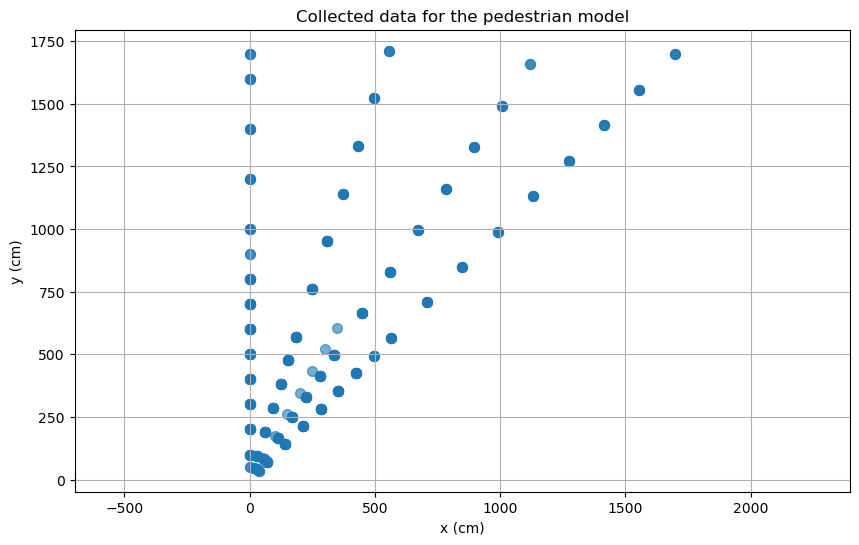

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Conversion en radians
second_exp['angle_rad'] = np.radians(second_exp['angle']).astype(np.float32)

# Conversion polaire → cartésien
second_exp['x'] = second_exp['distance'] * np.sin(second_exp['angle_rad'])
second_exp['y'] = second_exp['distance'] * np.cos(second_exp['angle_rad'])

# Tracer les points
plt.figure(figsize=(10, 6))
plt.scatter(second_exp['x'], second_exp['y'], alpha=0.6, s=50)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.title('Collected data for the pedestrian model')
plt.grid(True)
plt.axis('equal')  # Échelle équivalente sur x et y
plt.show()


In [40]:
second_exp.to_csv('pedestrian_data.csv', index=False)

In [41]:
def compute_angle_from_normalized_bbox(x_center_norm, image_width):
    """
    Converts a normalized x_center to relative angle in degrees
    """
   
    angle_raw = (x_center_norm / image_width) * 360
    relative_angle = (angle_raw) % 360

    if relative_angle > 180:
        relative_angle -= 360

    return relative_angle





In [42]:
thredshold_dist=1000

In [43]:
second_exp=second_exp.loc[second_exp['distance']<=2400]
second_exp_small=second_exp.loc[second_exp['distance'] <= thredshold_dist]
second_exp_big=second_exp.loc[second_exp['distance'] >= thredshold_dist]

In [44]:
second_exp_small

,x,y,w,h,Cx,Cy,W,H,distance,angle,x_center,y2,person,y_low,angle_rad
0,565.685415,565.685415,0.011445,0.076111,3307.073280,1442.692608,61.528320,204.586368,800.0,45.0,619.073280,1143.014208,4,0.425229,0.785398
1,279.596448,414.518803,0.016799,0.112180,3149.895168,1516.335744,90.311424,301.539840,500.0,34.0,461.895168,1020.894336,2,0.379797,0.593412
2,223.677158,331.615043,0.023380,0.135353,3140.148480,1553.397888,125.690880,363.828864,400.0,34.0,452.148480,952.687680,2,0.354422,0.593412
3,247.213602,760.845232,0.012323,0.069817,2911.060992,1453.807488,66.248448,187.668096,800.0,18.0,223.060992,1140.358464,2,0.424241,0.314159
4,707.106769,707.106769,0.008383,0.050309,3405.475584,1443.375360,45.067008,135.230592,1000.0,45.0,717.475584,1177.009344,7,0.437875,0.785398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,0.000000,200.000000,0.043341,0.228507,2727.088896,1706.769792,233.001216,614.226816,200.0,0.0,39.088896,674.116800,2,0.250787,0.000000
352,424.264061,424.264061,0.016733,0.094155,3371.708928,1484.324352,89.956608,253.088640,600.0,45.0,683.708928,1077.131328,2,0.400718,0.785398
353,494.974738,494.974738,0.013480,0.080443,3373.117440,1464.575616,72.468480,216.230784,700.0,45.0,685.117440,1115.308992,2,0.414922,0.785398
354,150.000000,259.807616,0.036035,0.174820,3099.382272,1605.300480,193.724160,469.916160,300.0,30.0,411.382272,847.741440,2,0.315380,0.523599


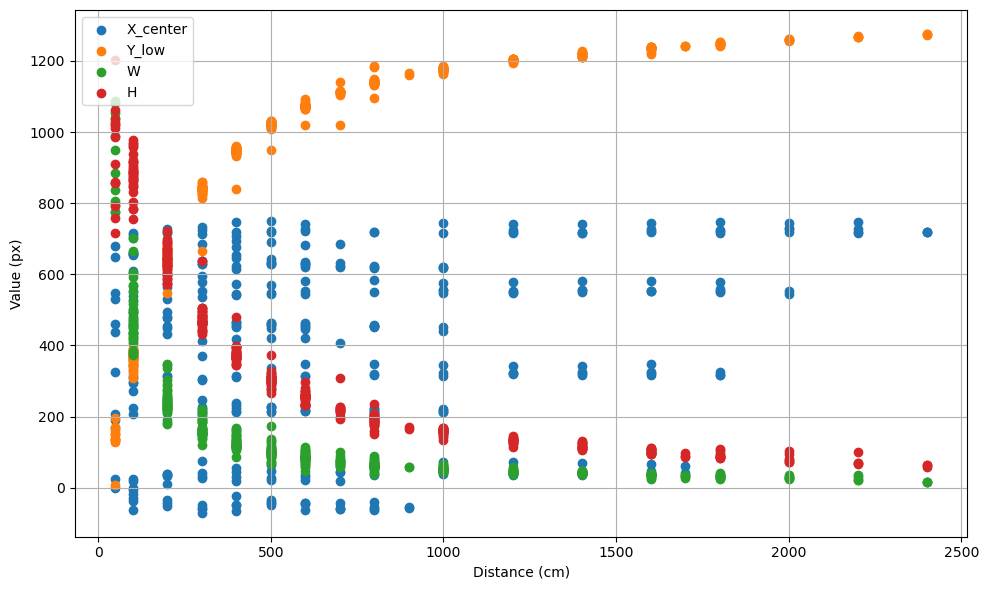

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

#plt.scatter(second_exp['distance'], second_exp['x_center'], label='Cx')
plt.scatter(second_exp['distance'], second_exp['x_center'], label='X_center')
plt.scatter(second_exp['distance'], second_exp['y2'], label='Y_low')
plt.scatter(second_exp['distance'], second_exp['W'], label='W')
plt.scatter(second_exp['distance'], second_exp['H'], label='H')

plt.xlabel('Distance (cm)')
plt.ylabel('Value (px)')
#plt.title('Points de Y_low, W et H en fonction de la distance')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


Split 1: 68/281 = 0.242
Split 2: 68/281 = 0.242
Split 3: 68/281 = 0.242
Split 4: 61/281 = 0.217
Split 5: 56/281 = 0.199
Split 6: 68/281 = 0.242
Split 7: 47/281 = 0.167
Split 8: 56/281 = 0.199
Split 9: 68/281 = 0.242
Split 10: 56/281 = 0.199
0.3903022467362479 117.12471749564402
0.4064011895195805 115.56804591152971
-0.29192499368878333 113.66287844713345
0.8466960331043333 116.68618805172461
0.21754972667776584 216.0036796910401
0.8453444708489619 78.65253439045382
0.21363260770961667 119.00008723916793
0.6569612747126474 228.8359926533874
0.4695120195979443 109.25190872038004
0.5471889062027211 230.04846573615083
Ordre 1: R² moyen = 0.4302, RMSE moyen = 144.48
0.8667398865226972 54.75721462272633
0.7916473702991433 68.46849033146032
0.3930499852448077 77.90699678175204
0.942218045276918 71.63724421441604
0.6883605727215953 136.3198109173895
0.8465219032351817 78.35256135310914
0.7790670781078219 63.07608788061207
0.8766871031971654 137.20091539567917
0.7470475146066935 75.441572898166

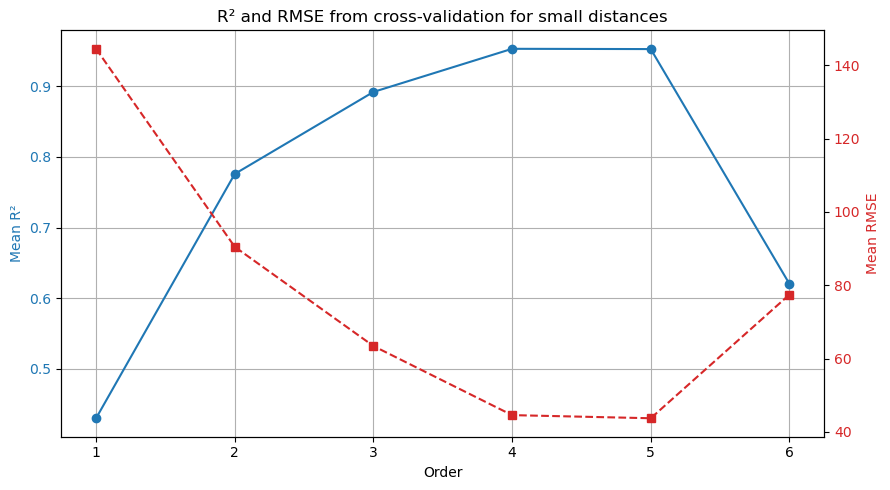

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split

# (Assuming second_exp_small is already defined)
# Définir 10 paires de distances pour les splits
dist_pairs = [
    [300, 600],
    [100, 400],
    [600, 400],
    [800, 200],
    [500, 1000],
    [200, 600],
    [400, 700],
    [1000, 200],
    [200, 500],
    [1000, 300]
]
splits = []

for pair in dist_pairs:
    test_data = second_exp_small.loc[second_exp_small['distance'].isin(pair)]
    training_data = second_exp_small.loc[~second_exp_small['distance'].isin(pair)]
    splits.append((training_data, test_data))

# Vérifier les ratios test/train
for i, (train, test) in enumerate(splits, 1):
    print(f"Split {i}: {len(test)}/{len(train)+len(test)} = {len(test)/(len(train)+len(test)):.3f}")

# Évaluation
def evaluate_polynomial_regression(splits, order):
    r2_dist_scores, rmse_scores = [], []

    for training_data_small, test_data_small in splits:
        X_train = training_data_small[["x_center", "y2"]].astype(int).values
        y_dist_train = training_data_small["distance"].round(1).values.flatten()

        X_test = test_data_small[["x_center","y2"]].astype(int).values
        y_dist_test = test_data_small["distance"].round(1).values.flatten()

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_dist = LinearRegression().fit(X_train_poly, y_dist_train)
        y_dist_pred = model_dist.predict(X_test_poly)

        r2_dist = r2_score(y_dist_test, y_dist_pred)
        rmse = np.sqrt(mean_squared_error(y_dist_test, y_dist_pred))

        r2_dist_scores.append(r2_dist)
        rmse_scores.append(rmse)
        print(r2_dist, rmse)
    return np.mean(r2_dist_scores), np.mean(rmse_scores)

# Itération sur les ordres
orders = range(1, 7)
r2_values = []
rmse_values = []

for order in orders:
    r2_moyen, rmse_moyen = evaluate_polynomial_regression(splits, order)
    r2_values.append(r2_moyen)
    rmse_values.append(rmse_moyen)
    print(f"Ordre {order}: R² moyen = {r2_moyen:.4f}, RMSE moyen = {rmse_moyen:.2f}")


best_degree_small_dist = orders[np.argmax(r2_values)]
# Affichage du graphique
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel("Order")
ax1.set_ylabel("Mean R²", color=color)
ax1.plot(orders, r2_values, marker='o', color=color, label='R² mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Second y-axis for RMSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Mean RMSE", color=color)
ax2.plot(orders, rmse_values, marker='s', linestyle='--', color=color, label='RMSE mean')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("R² and RMSE from cross-validation for small distances")
fig.tight_layout()
plt.show()


In [38]:
second_exp_big

,x,y,w,h,Cx,Cy,W,H,distance,angle,x_center,y2,person,y_low,angle_rad
4,707.106769,707.106769,0.008383,0.050309,3405.475584,1443.375360,45.067008,135.230592,1000.0,45.0,717.475584,1177.009344,7,0.437875,0.785398
8,671.031475,994.845128,0.010973,0.052491,3265.511424,1422.511104,58.990848,141.095808,1200.0,34.0,577.511424,1194.940992,6,0.444547,0.593412
9,0.000000,1200.000000,0.008401,0.049392,2734.061568,1416.941568,45.163776,132.765696,1200.0,0.0,46.061568,1204.675584,8,0.448168,0.000000
18,671.031475,994.845128,0.007505,0.047283,3236.819712,1423.349760,40.346880,127.096704,1200.0,34.0,548.819712,1201.101888,7,0.446838,0.593412
19,707.106769,707.106769,0.011740,0.059863,3432.920064,1431.709440,63.114240,160.911744,1000.0,45.0,744.920064,1175.834688,6,0.437438,0.785398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,894.708633,1326.460171,0.007094,0.036055,3241.926912,1400.509824,38.137344,96.915840,1600.0,34.0,553.926912,1239.032256,1,0.460950,0.593412
326,494.427204,1521.690464,0.006804,0.039430,3013.301760,1397.811072,36.578304,105.987840,1600.0,18.0,325.301760,1237.195008,8,0.460266,0.314159
332,1697.056246,1697.056246,0.003115,0.023581,3406.252372,1380.476688,16.748265,63.385743,2400.0,45.0,718.252372,1275.830441,8,0.474639,0.785398
333,1006.547213,1492.267692,0.006175,0.033262,3241.042429,1391.559080,33.197845,89.407832,1800.0,34.0,553.042429,1251.737005,8,0.465676,0.593412


Split 1: 15/75 = 0.200
Split 2: 15/70 = 0.214
Split 3: 15/70 = 0.214
Split 4: 9/88 = 0.102
Split 5: 15/77 = 0.195
Split 6: 15/72 = 0.208
Split 7: 15/82 = 0.183
Split 8: 15/65 = 0.231
Split 9: 15/75 = 0.200
Split 10: 15/64 = 0.234
0.9563611167369153 73.90296799598379
0.7934364393096341 89.06200497692632
0.9459181335012966 69.61131544715862
-0.19691758850707042 206.29364947468628
0.8349471513083131 107.79480761101048
0.8438439481419302 188.0627838744549
0.7147520393060683 94.4727037187704
0.7373789457043167 100.42235052494159
0.8711948833529612 86.13463135620556
0.7732803056876282 179.56775530882052
Ordre 1: R² moyen = 0.7274, RMSE moyen = 119.53
0.987143688876166 40.11282539411198
0.925642158936328 53.435391800238605
0.9649404407301535 56.04762716278221
0.8817308112083978 64.84694836760093
0.9318942849884325 69.24335590375694
0.9808265251724717 65.89824739570814
0.9169942138891366 50.962327446435204
0.8812835046771386 67.5182450926998
0.9483441364845732 54.547023186316856
0.937903443534

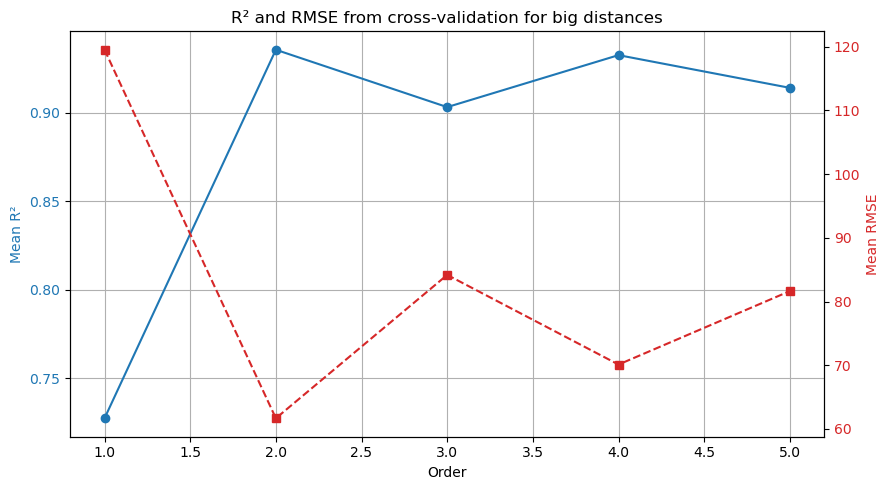

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# (Assuming second_exp_small is already defined)

# Définir les 10 splits
dist_pairs = [
    [1200, 2000],
    [1800, 1400],
    [1200, 1800],
    [2000, 2400],
    [1600, 2200],
    [1000, 2400],
    [1800, 2200],
    [1200, 1600],
    [1400, 2000],
    [1000, 1800]
]

splits = []

for pair in dist_pairs:
    test_data = second_exp_big.loc[second_exp_big['distance'].isin(pair)].head(15)
    training_data = second_exp_big.loc[~second_exp_big['distance'].isin(pair)]
    splits.append((training_data, test_data))

# Vérifier les ratios test/train
for i, (train, test) in enumerate(splits, 1):
    print(f"Split {i}: {len(test)}/{len(train)} = {len(test)/len(train):.3f}")

# Évaluation
def evaluate_polynomial_regression(splits, order):
    r2_dist_scores, rmse_scores = [], []

    for training_data_small, test_data_small in splits:
        X_train = training_data_small[[ "x_center","y2"]].values
        y_dist_train = training_data_small["distance"].round(1).values.flatten()

        X_test = test_data_small[[ "x_center","y2"]].values
        y_dist_test = test_data_small["distance"].round(1).values.flatten()

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_dist = LinearRegression().fit(X_train_poly, y_dist_train)
        y_dist_pred = model_dist.predict(X_test_poly)

        r2_dist = r2_score(y_dist_test, y_dist_pred)
        rmse = np.sqrt(mean_squared_error(y_dist_test, y_dist_pred))

        r2_dist_scores.append(r2_dist)
        rmse_scores.append(rmse)
        print(r2_dist, rmse)
    return np.mean(r2_dist_scores), np.mean(rmse_scores)

# Itération sur les ordres
orders = range(1, 6)
r2_values = []
rmse_values = []

for order in orders:
    r2_moyen, rmse_moyen = evaluate_polynomial_regression(splits, order)
    r2_values.append(r2_moyen)
    rmse_values.append(rmse_moyen)
    print(f"Ordre {order}: R² moyen = {r2_moyen:.4f}, RMSE moyen = {rmse_moyen:.2f}")

best_degree_big_dist = orders[np.argmin(rmse_values)]
# Affichage du graphique
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel("Order")
ax1.set_ylabel("Mean R²", color=color)
ax1.plot(orders, r2_values, marker='o', color=color, label='R² mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Second y-axis for RMSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Mean RMSE", color=color)
ax2.plot(orders, rmse_values, marker='s', linestyle='--', color=color, label='RMSE mean')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("R² and RMSE from cross-validation for big distances")
fig.tight_layout()
plt.show()


## Model

In [55]:
second_exp

,x,y,w,h,Cx,Cy,W,H,distance,angle,x_center,y2,person,y_low,angle_rad
0,565.685415,565.685415,0.011445,0.076111,3307.073280,1442.692608,61.528320,204.586368,800.0,45.0,619.073280,1143.014208,4,0.425229,0.785398
1,279.596448,414.518803,0.016799,0.112180,3149.895168,1516.335744,90.311424,301.539840,500.0,34.0,461.895168,1020.894336,2,0.379797,0.593412
2,223.677158,331.615043,0.023380,0.135353,3140.148480,1553.397888,125.690880,363.828864,400.0,34.0,452.148480,952.687680,2,0.354422,0.593412
3,247.213602,760.845232,0.012323,0.069817,2911.060992,1453.807488,66.248448,187.668096,800.0,18.0,223.060992,1140.358464,2,0.424241,0.314159
4,707.106769,707.106769,0.008383,0.050309,3405.475584,1443.375360,45.067008,135.230592,1000.0,45.0,717.475584,1177.009344,7,0.437875,0.785398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,0.000000,200.000000,0.043341,0.228507,2727.088896,1706.769792,233.001216,614.226816,200.0,0.0,39.088896,674.116800,2,0.250787,0.000000
352,424.264061,424.264061,0.016733,0.094155,3371.708928,1484.324352,89.956608,253.088640,600.0,45.0,683.708928,1077.131328,2,0.400718,0.785398
353,494.974738,494.974738,0.013480,0.080443,3373.117440,1464.575616,72.468480,216.230784,700.0,45.0,685.117440,1115.308992,2,0.414922,0.785398
354,150.000000,259.807616,0.036035,0.174820,3099.382272,1605.300480,193.724160,469.916160,300.0,30.0,411.382272,847.741440,2,0.315380,0.523599


In [17]:
calibration_values_small = pd.DataFrame(second_exp_small[[ "y_low"]])
distance_values_small = pd.DataFrame(second_exp_small["distance"]).round(1)

calibration_values_big = pd.DataFrame(second_exp_big[[ "y_low"]])
distance_values_big = pd.DataFrame(second_exp_big["distance"]).round(1)

calibration_values = pd.DataFrame(second_exp[["x_center"]]).astype(int)
angle_values = pd.DataFrame(second_exp["angle"]).round(1)
distance_values = pd.DataFrame(second_exp["distance"]).round(1)


In [19]:
import joblib
def dist_est(c_x, c_y):
    distance_features, distance_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/Pedestrian/distance_predictor_small.joblib')
    image_data =pd.DataFrame([[c_x, c_y]], columns=[ "x_center","y2"])
    cur_dist = distance_model.predict(distance_features.transform(image_data))[0][0]
    if cur_dist >thredshold_dist:
        distance_features, distance_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/Pedestrian/distance_predictor_big.joblib')
        image_data =pd.DataFrame([[c_x, c_y]], columns=["x_center","y2"])

        cur_dist = distance_model.predict(distance_features.transform(image_data))[0][0]
 
    return cur_dist if 0 <= cur_dist <= 2600 else float('inf')

def ang_est(c_x):
    angle_features, angle_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/Pedestrian/angle_predictor.joblib')
    image_data =pd.DataFrame([[c_x]], columns=["x_center"])

    cur_angle = angle_model.predict(angle_features.transform(image_data))[0][0]
    return cur_angle if -15 <= cur_angle <= 100 else float('inf')


def get_ang_dist(c_x, c_y):
    width = 5376
    segment = width / 8  # 672

    if 0 < c_x < segment:
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)

    elif segment <= c_x < 2 * segment:
        c_x = c_x - segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang += 45

    elif 2 * segment <= c_x < 3 * segment:
        c_x = c_x - 2 * segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang += 90

    elif 3 * segment <= c_x:
        c_x = c_x - 3 * segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang += 135

    elif -segment < c_x < 0:
        c_x = -c_x
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang

    elif -2 * segment < c_x <= -segment:
        c_x = -c_x - segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang - 45

    elif -3 * segment < c_x <= -2 * segment:
        c_x = -c_x - 2 * segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang - 90

    elif c_x <= -3 * segment:
        c_x = -c_x - 3 * segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang - 135

    else:
        cur_dist = float('inf')
        cur_ang = float('inf')

    return cur_ang, cur_dist



In [20]:
from math import sqrt, atan2, degrees

def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)\.txt', filename)
    if match:
        x, y, = match.groups()
        return float(x), float(y)
    return None, None

def load_yolo_labels_from_folder(folder_path):
    """Charge tous les fichiers YOLO d'un dossier et retourne une DataFrame avec les colonnes demandées."""
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            angle,distance = parse_filename(filename)
 
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=y-height/2
                        distance=distance
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)


# Exemple d'utilisation
val= load_yolo_labels_from_folder('/Users/martin.dejaeghere/Position_Estimation/Pedestrian/third_exp/labels')
#val=load_yolo_labels_from_folder('/Users/martin.dejaeghere/Position_Estimation/escooter/labels-studio')
val=load_yolo_labels_from_folder('/Users/martin.dejaeghere/Position_Estimation/Pedestrian/slope/labels-studio')

## Validation

In [21]:
def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)-P(\d+)\.txt', filename)
    if match:
        angle, distance, person = match.groups()
        return float(angle), float(distance), int(person)
    return None, None, None

def load_yolo_labels_from_folder(folder_path):
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","person","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            angle, distance, person = parse_filename(filename)
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=y-height/2
                        distance=distance
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,person,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)

first_exp= load_yolo_labels_from_folder("/Users/martin.dejaeghere/Position_Estimation/Pedestrian/Experiment_FUSE/renamed_labels")
val2=first_exp.loc[first_exp['person']==1]

In [22]:
calibration_test_values=val[["x_center", "y2"]].astype(int)
angle_test_values=pd.DataFrame(val["angle"])
distance_test_values=pd.DataFrame(val["distance"])

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_32824/3280112082.py:32: RuntimeWarning: invalid value encountered in multiply
  pred_x = yhat_dist * np.sin(np.radians(yhat_ang))


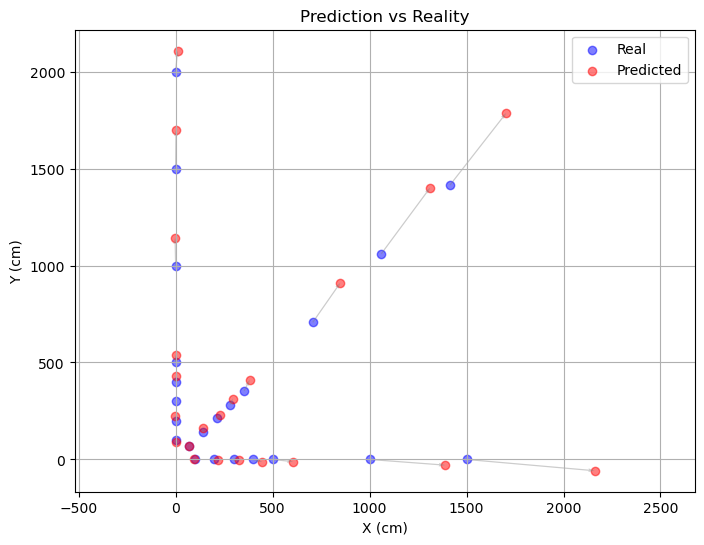

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures



yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y = row["x_center"], row["y2"]
    ang, dist = get_ang_dist(c_x, c_y)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_dist = np.array(yhat_dist)

# Remplacer la prédiction angulaire par le calcul depuis Xc
image_width = 5376  
Xc_test = calibration_test_values['x_center'].values
yhat_ang = np.array([compute_angle_from_normalized_bbox(x, image_width) for x in Xc_test])

# Valeurs réelles
true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))

pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Vecteurs d'erreur (flèches de réel -> prédit)
dx = pred_x - real_x
dy = pred_y - real_y

# Tracé
plt.figure(figsize=(8, 6))

plt.scatter(real_x, real_y, c='blue', label='Real', alpha=0.5)
plt.scatter(pred_x, pred_y, c='red', label='Predicted', alpha=0.5)
plt.quiver(real_x, real_y, dx, dy, angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.4, width=0.002)

plt.axis('equal')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title("Prediction vs Reality")
plt.legend()
plt.grid(True)
plt.show()


/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_32824/2497438562.py:39: RuntimeWarning: invalid value encountered in multiply
  pred_x = yhat_dist * np.sin(np.radians(yhat_ang))


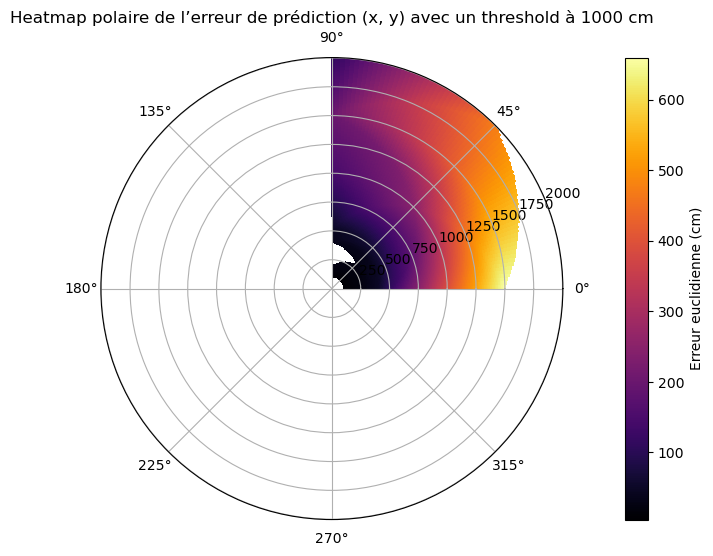

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y = row["x_center"], row["y2"]
    ang, dist = get_ang_dist(c_x, c_y)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)

x_vals = calibration_test_values['x_center'].values
y_vals = calibration_test_values['y2'].values

yhat_ang = []
yhat_dist = []

for c_x, c_y in zip(x_vals, y_vals):
    ang, dist = get_ang_dist(c_x, c_y)
    angle=compute_angle_from_normalized_bbox(c_x, 5376)
    yhat_ang.append(angle)
    yhat_dist.append(dist)

yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)

true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

# Étape 2: conversion en coordonnées cartésiennes
real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))
pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Étape 3: calcul de l’erreur (distance euclidienne)
error = np.sqrt((real_x - pred_x)**2 + (real_y - pred_y)**2)

# Coordonnées polaires basées sur les réels (ou prédits)
theta = np.arctan2(real_y, real_x)
r = np.sqrt(real_x**2 + real_y**2)

# Étape 4: création d'une grille polaire
theta_grid, r_grid = np.meshgrid(
    np.linspace(-np.pi, np.pi, 300),
    np.linspace(min(r), max(r), 300)
)

# Interpolation des erreurs sur la grille
error_grid = griddata(
    points=(theta, r),
    values=error,
    xi=(theta_grid, r_grid),
    method='linear'
)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6))
c = ax.pcolormesh(theta_grid, r_grid, error_grid, cmap='inferno', shading='auto')
cb = plt.colorbar(c, ax=ax, orientation='vertical', pad=0.1)
cb.set_label('Erreur euclidienne (cm)')
ax.set_title(f'Heatmap polaire de l’erreur de prédiction (x, y) avec un threshold à {thredshold_dist} cm')
plt.show()

